# TASK 1
 Use a grouped bar chart to compare the average rating and total review count for the top 10 app categories by number of installs. Filter out any categories where the average rating is below 4.0 and size below 10 M and last update should be Jan month . this graph should work only between 3PM IST to 5 PM IST apart from that time we should not show this graph in dashboard itself.



Task 1: 

Import Required Libraries

Imported Python libraries required for data analysis and visualization:

Pandas for data manipulation

NumPy for numerical operations

Matplotlib and Seaborn for visualization

Datetime and pytz for time-based restrictions

Task 2: 

Load the Dataset

Loaded the Google Play Store dataset from a CSV file using Pandas.


Step 1: Remove Duplicate and Missing Data

Step 2: Convert Rating and Reviews to Numeric

Step 3: Clean and Convert Installs Column

Step 4: Convert App size into Mb

Step 5: Convert last update  

Step 6: Remove Conversion Errors

Step 7: Apply Business Filters

Step 8: Apply graph in between 3 pm to 5 pm









 
 

In [3]:
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pytz

    

In [ ]:
import pandas as pd

play_store_data = pd.read_csv(
    r"C:\Users\Vansh Sharma\Downloads\Play Store Data (1).csv"
)

print(play_store_data.head())

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

In [6]:
play_store_data.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
play_store_data.tail(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


# =====================================
# Step 1: Remove Duplicate and Missing Data
# =====================================

In [78]:

play_store_data = play_store_data.drop_duplicates()

play_store_data = play_store_data.dropna(
    subset=[
        'Category',
        'Rating',
        'Reviews',
        'Installs',
        'Size',
        'Last Updated'
    ]
)


# =====================================
# Step 2: Convert Rating and Reviews to Numeric
# =====================================

In [79]:
play_store_data['Rating'] = pd.to_numeric(
    play_store_data['Rating'],
    errors='coerce'
)

play_store_data['Reviews'] = pd.to_numeric(
    play_store_data['Reviews'],
    errors='coerce'
)

# =====================================
# Step 3: Clean and Convert Installs Column
# =====================================

In [80]:

# Convert installs into string format
play_store_data['Installs'] = play_store_data['Installs'].astype(str)

# Remove commas and plus sign
play_store_data['Installs'] = (
    play_store_data['Installs']
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

# Convert installs into numeric
play_store_data['Installs'] = pd.to_numeric(
    play_store_data['Installs'],
    errors='coerce'
)

# =====================================
# Step 4: Convert App Size into MB
# =====================================

In [81]:



def convert_size(size):

    if pd.isna(size):
        return np.nan

    size = str(size)

    if size.endswith('M'):
        return float(size[:-1])

    elif size.endswith('k'):
        return float(size[:-1]) / 1024

    else:
        return np.nan
    
    # Create new Size_MB column
play_store_data['Size_MB'] = (
    play_store_data['Size'].apply(convert_size)
)


# =====================================
# Step 5: Convert Last Updated Date
# =====================================

In [82]:


play_store_data['Last Updated'] = pd.to_datetime(
    play_store_data['Last Updated'],
    errors='coerce'
)


# Extract month from date
play_store_data['Update_Month'] = (
    play_store_data['Last Updated'].dt.month_name()
)




# =====================================
# Step 6: Remove Conversion Errors
# =====================================

In [83]:


play_store_data = play_store_data.dropna(
    subset=[
        'Rating',
        'Reviews',
        'Installs',
        'Size_MB',
        'Last Updated'
    ]
)



# =====================================
# Step 7: Apply Business Filters
# =====================================

In [84]:
filtered = play_store_data[
    (play_store_data['Rating'] >= 4.0) &
    (play_store_data['Size_MB'] >= 10) &
    (play_store_data['Update_Month'] == 'January')
]


# Display filtered data
filtered.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Update_Month
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,January
33,Easy Origami Ideas,ART_AND_DESIGN,4.2,1015.0,11M,100000.0,Free,0,Everyone,Art & Design,2018-01-06,1.1.0,4.1 and up,11.0,January
44,Popsicle Sticks and Similar DIY Craft Ideas,ART_AND_DESIGN,4.2,26.0,12M,10000.0,Free,0,Everyone,Art & Design,2018-01-03,1.0.0,4.1 and up,12.0,January
446,Video Caller Id,COMMUNICATION,4.2,15287.0,17M,1000000.0,Free,0,Everyone,Communication,2018-01-24,2.2.245,4.0.3 and up,17.0,January
719,Monster Truck Driver & Racing,EDUCATION,4.4,748.0,51M,1000000.0,Free,0,Everyone,Education;Action & Adventure,2017-01-19,1.0.9,2.3 and up,51.0,January


           Category    Rating    Reviews
2            FAMILY  4.395455  4544623.0
3              GAME  4.313333  2397589.0
7            SPORTS  4.342857  1982017.0
1     ENTERTAINMENT  4.300000   869111.0
6       PHOTOGRAPHY  4.150000   563720.0
5   PERSONALIZATION  4.475000   155996.0
0         EDUCATION  4.400000    57645.0
4         LIFESTYLE  4.380000    42809.0
8             TOOLS  4.200000     8010.0
9  TRAVEL_AND_LOCAL  4.100000      974.0


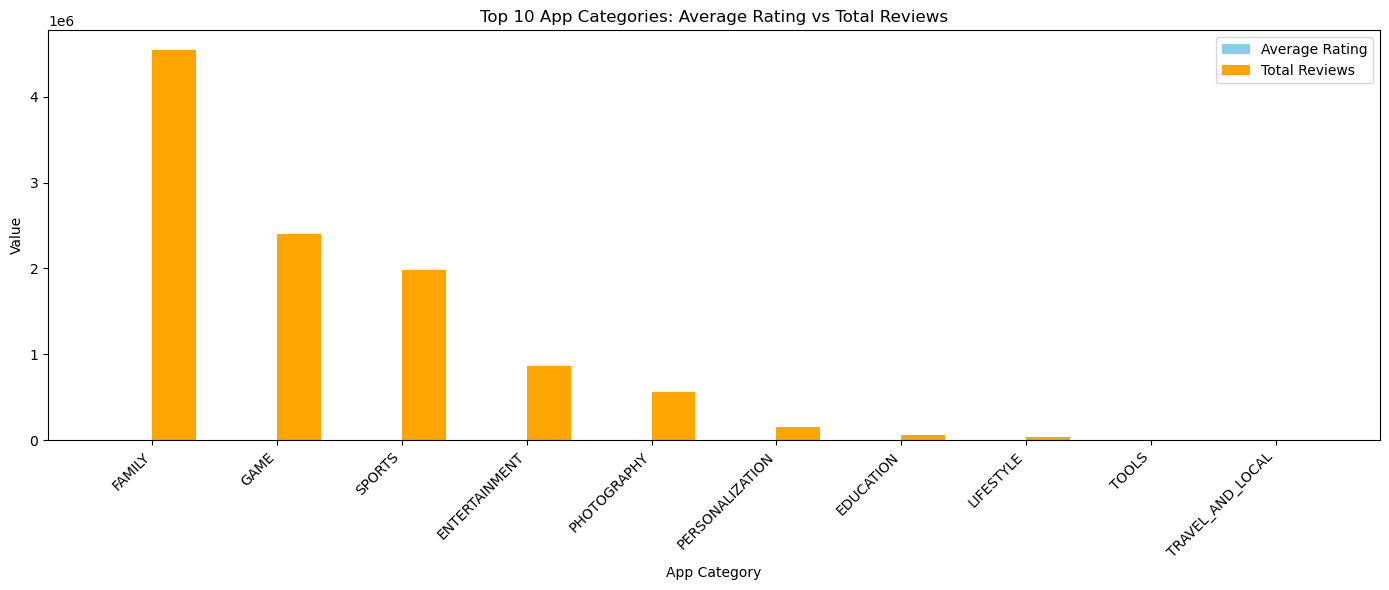

In [85]:

top_categories = (
    filtered.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

final_df = filtered[
    filtered['Category'].isin(top_categories)
]

summary = (
    final_df.groupby('Category')
    .agg({
        'Rating':'mean',
        'Reviews':'sum'
    })
    .reset_index()
)

summary = summary.sort_values(
    by='Reviews',
    ascending=False
)

summary = (
    final_df.groupby('Category')
    .agg({
        'Rating':'mean',
        'Reviews':'sum'
    })
    .reset_index()
)

summary = summary.sort_values(
    by='Reviews',
    ascending=False
)

print(summary)

x = np.arange(len(summary))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(
    x - width/2,
    summary['Rating'],
    width,
    label='Average Rating',
    color='skyblue'
)

plt.bar(
    x + width/2,
    summary['Reviews'],
    width,
    label='Total Reviews',
    color='orange'
)

plt.xticks(
    x,
    summary['Category'],
    rotation=45,
    ha='right'
)

plt.xlabel("App Category")
plt.ylabel("Value")
plt.title("Top 10 App Categories: Average Rating vs Total Reviews")

plt.legend()

plt.tight_layout()
plt.show()


# =====================================
# Step 8: Apply graph in between 3 pm to 5 pm
# =====================================

In [86]:
ist = pytz.timezone("Asia/Kolkata")

if (
    current_time >= datetime.strptime("16:00", "%H:%M").time()
    and
    current_time <= datetime.strptime("17:00", "%H:%M").time()
):
    
    # yaha tumhara plotting code hoga

 

    x = np.arange(len(summary))
    width = 0.35

    plt.figure(figsize=(14,6))

    plt.bar(x-width/2, summary['Rating'], width, label='Average Rating')
    plt.bar(x+width/2, summary['Reviews'], width, label='Total Reviews')

    plt.xticks(x, summary['Category'], rotation=45, ha='right')

    plt.xlabel("Category")
    plt.ylabel("Values")
    plt.title("Average Rating vs Total Reviews")

    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("This graph is available only between 3:00 PM and 5:00 PM IST.")

print(current_time)

This graph is available only between 3:00 PM and 5:00 PM IST.
03:59:57.430596
